In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

import tensorflow as tf

from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

In [3]:
import pandas as pd

# Changed "blob" to "raw" in the URL
DATA_URL = "https://raw.githubusercontent.com/Nrrahat/ANN_assingment/main/ANN_assingment/data/heart_disease.csv"

df = pd.read_csv(DATA_URL)

print(df.shape)

(1025, 14)


In [4]:
TARGET = "target"

X = df.drop(columns=[TARGET])

y = df[TARGET]

In [5]:
num_cols = X.select_dtypes(include=np.number).columns

cat_cols = X.select_dtypes(exclude=np.number).columns

In [6]:
num_imputer = SimpleImputer(strategy="median")

X[num_cols] = num_imputer.fit_transform(
    X[num_cols]
)

In [8]:
if len(cat_cols) > 0:

    cat_imputer = SimpleImputer(
        strategy="most_frequent"
    )

    X[cat_cols] = cat_imputer.fit_transform(
        X[cat_cols]
    )

In [9]:
if len(cat_cols) > 0:

    cat_imputer = SimpleImputer(
        strategy="most_frequent"
    )

    X[cat_cols] = cat_imputer.fit_transform(
        X[cat_cols]
    )

In [10]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [12]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=42
)

In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

Shallow Neural Network

In [15]:
def build_shallow_model(
    input_dim,
    hidden_units=32,
    activation="relu"
):

    model = Sequential([
        Dense(
            hidden_units,
            activation=activation,
            input_shape=(input_dim,)
        ),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

Hyperparameter Tunning


In [16]:
hidden_units_list = [16,32,64,128]

activations = [
    "relu",
    "sigmoid"
]

batch_sizes = [
    16,
    32,
    64
]

In [17]:
best_score = 0

best_shallow_model = None

best_history = None

In [18]:
for hidden in hidden_units_list:

    for activation in activations:

        for batch_size in batch_sizes:

            model = build_shallow_model(
                input_dim=X_train.shape[1],
                hidden_units=hidden,
                activation=activation
            )

            history = model.fit(
                X_train,
                y_train,
                validation_data=(
                    X_val,
                    y_val
                ),
                epochs=50,
                batch_size=batch_size,
                verbose=0
            )

            preds = (
                model.predict(X_val)
                > 0.5
            ).astype(int)

            score = f1_score(
                y_val,
                preds
            )

            if score > best_score:

                best_score = score

                best_shallow_model = model

                best_history = history

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


Deep Neural Network

In [21]:
def build_deep_model(
    input_dim,
    learning_rate,
    optimizer_name
):

    model = tf.keras.Sequential([

        tf.keras.layers.Input(shape=(input_dim,)),

        tf.keras.layers.Dense(
            128,
            activation="relu"
        ),

        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Dense(
            64,
            activation="relu"
        ),

        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Dense(
            32,
            activation="relu"
        ),

        tf.keras.layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    if optimizer_name == "adam":

        optimizer = tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        )

    else:

        optimizer = tf.keras.optimizers.SGD(
            learning_rate=learning_rate
        )

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

Deep NN hypertunning

In [20]:
learning_rates = [
    0.1,
    0.01,
    0.001
]

optimizers = [
    "adam",
    "sgd"
]

epoch_options = [
    50,
    100,
    150
]

In [22]:
best_deep_score = 0

best_deep_model = None

best_deep_history = None

best_deep_params = None

In [23]:
for lr in learning_rates:

    for opt in optimizers:

        for epochs in epoch_options:

            model = build_deep_model(
                input_dim=X_train.shape[1],
                learning_rate=lr,
                optimizer_name=opt
            )

            early_stop = tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=10,
                restore_best_weights=True
            )

            history = model.fit(
                X_train,
                y_train,
                validation_data=(
                    X_val,
                    y_val
                ),
                epochs=epochs,
                batch_size=32,
                verbose=0,
                callbacks=[early_stop]
            )

            val_probs = model.predict(
                X_val,
                verbose=0
            )

            val_preds = (
                val_probs > 0.5
            ).astype(int)

            score = f1_score(
                y_val,
                val_preds
            )

            if score > best_deep_score:

                best_deep_score = score

                best_deep_model = model

                best_deep_history = history

                best_deep_params = {
                    "learning_rate": lr,
                    "optimizer": opt,
                    "epochs": epochs
                }

Best Parameters

In [24]:
print("Best Deep Model")

print(best_deep_params)

print("Best Validation F1:",
      round(best_deep_score,4))

Best Deep Model
{'learning_rate': 0.1, 'optimizer': 'sgd', 'epochs': 150}
Best Validation F1: 0.9762


Shallow Predictions

In [25]:
shallow_probs = best_shallow_model.predict(
    X_test,
    verbose=0
)

shallow_preds = (
    shallow_probs > 0.5
).astype(int)

Deep Predictions

In [26]:
deep_probs = best_deep_model.predict(
    X_test,
    verbose=0
)

deep_preds = (
    deep_probs > 0.5
).astype(int)

Shallow Metrics

In [27]:
shallow_metrics = {

    "Accuracy":
        accuracy_score(
            y_test,
            shallow_preds
        ),

    "Precision":
        precision_score(
            y_test,
            shallow_preds
        ),

    "Recall":
        recall_score(
            y_test,
            shallow_preds
        ),

    "F1":
        f1_score(
            y_test,
            shallow_preds
        ),

    "AUC":
        roc_auc_score(
            y_test,
            shallow_probs
        )
}

Deep Metrics

In [28]:
deep_metrics = {

    "Accuracy":
        accuracy_score(
            y_test,
            deep_preds
        ),

    "Precision":
        precision_score(
            y_test,
            deep_preds
        ),

    "Recall":
        recall_score(
            y_test,
            deep_preds
        ),

    "F1":
        f1_score(
            y_test,
            deep_preds
        ),

    "AUC":
        roc_auc_score(
            y_test,
            deep_probs
        )
}

In [29]:
print("Shallow Neural Network")

for k,v in shallow_metrics.items():

    print(
        f"{k}: {v:.4f}"
    )


Shallow Neural Network
Accuracy: 0.9659
Precision: 0.9623
Recall: 0.9714
F1: 0.9668
AUC: 0.9879


In [30]:
print("\nDeep Neural Network")

for k,v in deep_metrics.items():

    print(
        f"{k}: {v:.4f}"
    )


Deep Neural Network
Accuracy: 0.9707
Precision: 0.9541
Recall: 0.9905
F1: 0.9720
AUC: 0.9972


Create Comparison DataFrame

In [31]:
comparison_df = pd.DataFrame({

    "Metric":
        list(
            shallow_metrics.keys()
        ),

    "Shallow":
        list(
            shallow_metrics.values()
        ),

    "Deep":
        list(
            deep_metrics.values()
        )
})

comparison_df

,Metric,Shallow,Deep
0,Accuracy,0.965854,0.970732
1,Precision,0.962264,0.954128
2,Recall,0.971429,0.990476
3,F1,0.966825,0.971963
4,AUC,0.987905,0.997238


Training History Plot

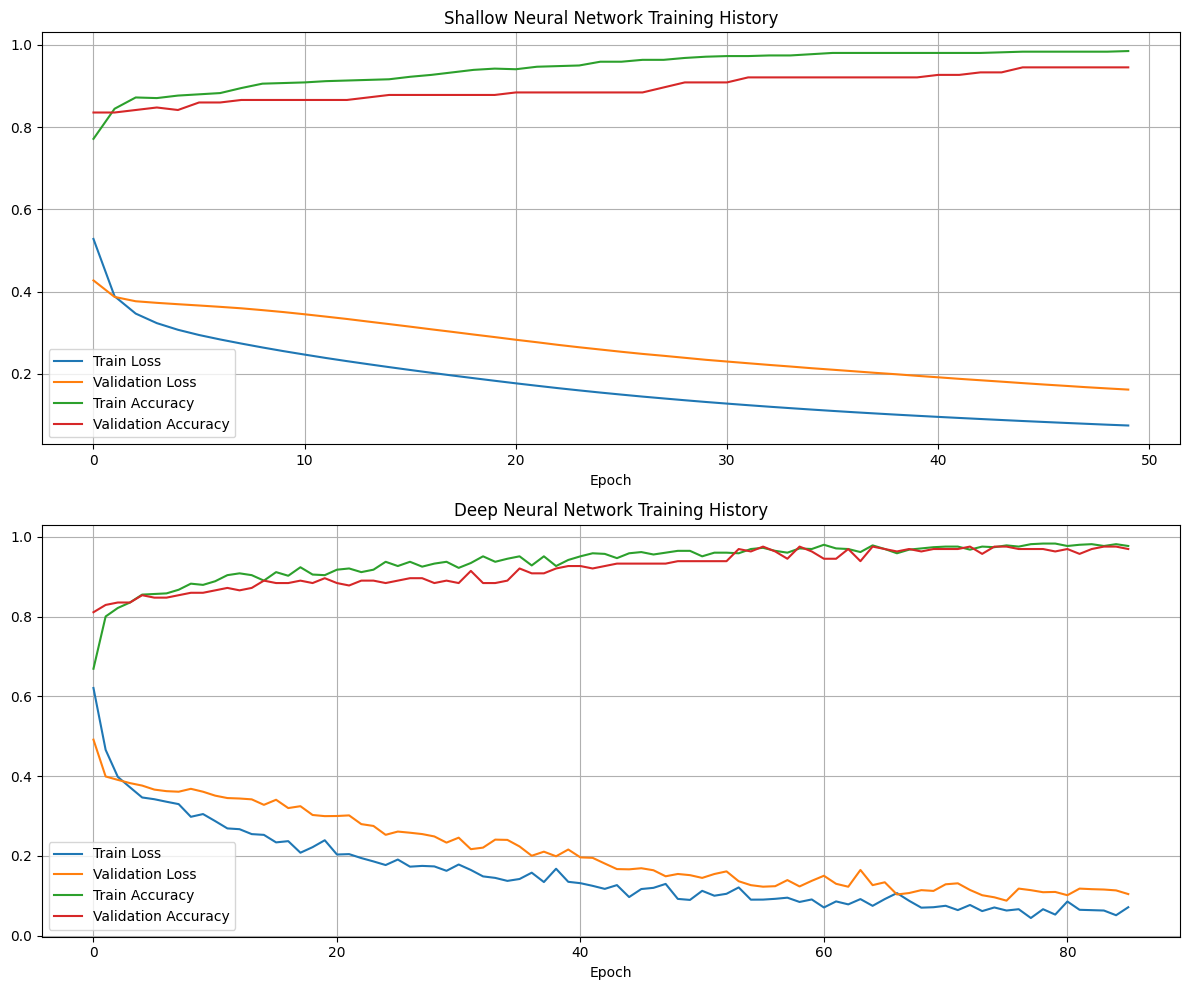

In [32]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(12,10)
)

# --------------------------
# Shallow Network
# --------------------------

axes[0].plot(
    best_history.history['loss'],
    label='Train Loss'
)

axes[0].plot(
    best_history.history['val_loss'],
    label='Validation Loss'
)

axes[0].plot(
    best_history.history['accuracy'],
    label='Train Accuracy'
)

axes[0].plot(
    best_history.history['val_accuracy'],
    label='Validation Accuracy'
)

axes[0].set_title(
    'Shallow Neural Network Training History'
)

axes[0].set_xlabel('Epoch')

axes[0].legend()

axes[0].grid(True)

# --------------------------
# Deep Network
# --------------------------

axes[1].plot(
    best_deep_history.history['loss'],
    label='Train Loss'
)

axes[1].plot(
    best_deep_history.history['val_loss'],
    label='Validation Loss'
)

axes[1].plot(
    best_deep_history.history['accuracy'],
    label='Train Accuracy'
)

axes[1].plot(
    best_deep_history.history['val_accuracy'],
    label='Validation Accuracy'
)

axes[1].set_title(
    'Deep Neural Network Training History'
)

axes[1].set_xlabel('Epoch')

axes[1].legend()

axes[1].grid(True)

plt.tight_layout()

plt.show()

Confusion Matrix Heatmap

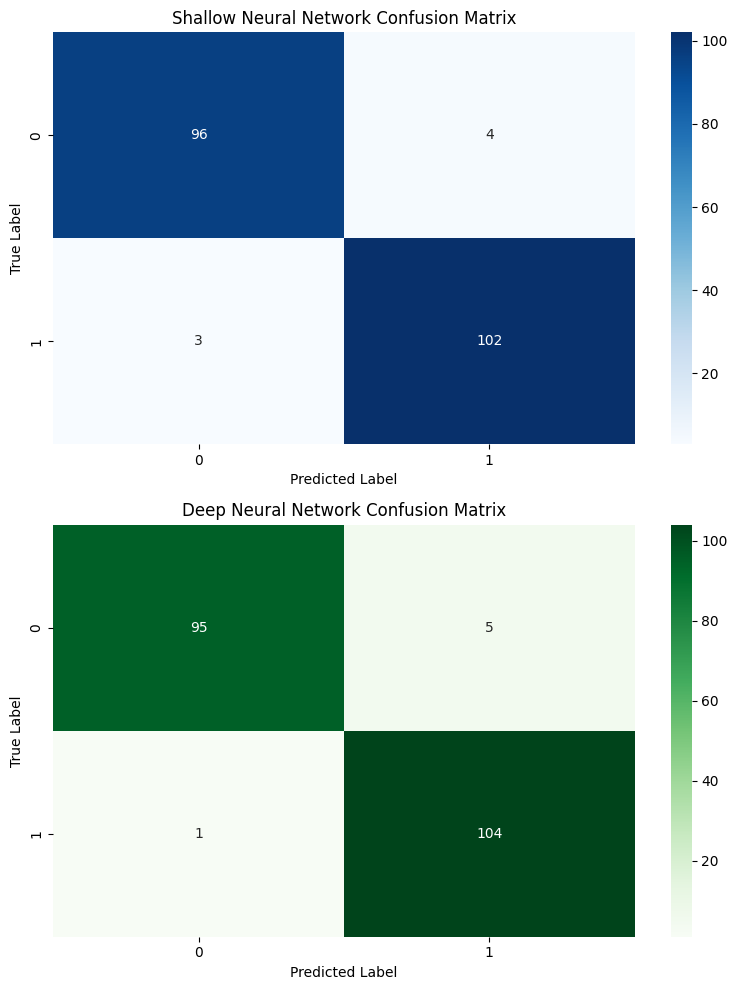

In [33]:
shallow_cm = confusion_matrix(
    y_test,
    shallow_preds
)

deep_cm = confusion_matrix(
    y_test,
    deep_preds
)
fig, axes = plt.subplots(
    2,
    1,
    figsize=(8,10)
)

# --------------------------
# Shallow
# --------------------------

sns.heatmap(
    shallow_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)

axes[0].set_title(
    'Shallow Neural Network Confusion Matrix'
)

axes[0].set_xlabel(
    'Predicted Label'
)

axes[0].set_ylabel(
    'True Label'
)

# --------------------------
# Deep
# --------------------------

sns.heatmap(
    deep_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=axes[1]
)

axes[1].set_title(
    'Deep Neural Network Confusion Matrix'
)

axes[1].set_xlabel(
    'Predicted Label'
)

axes[1].set_ylabel(
    'True Label'
)

plt.tight_layout()

plt.show()

ROC Curve

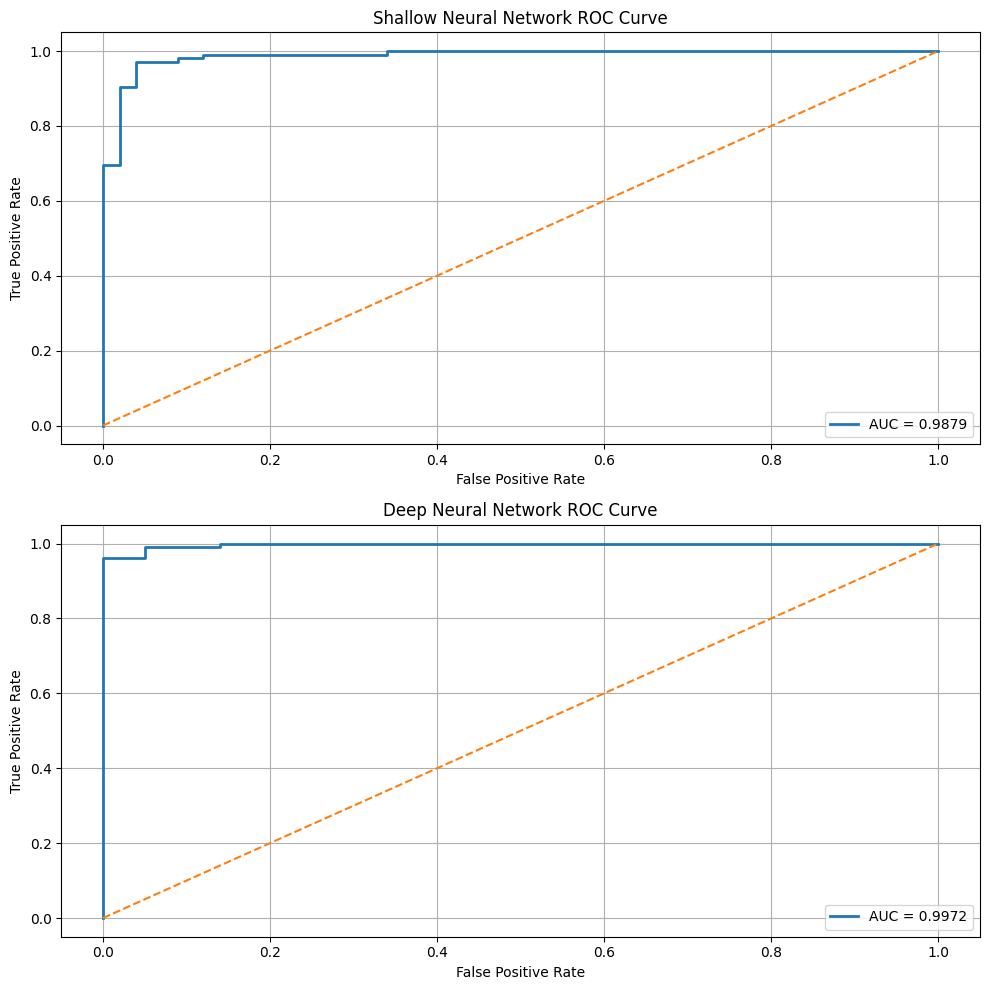

In [34]:
shallow_fpr, shallow_tpr, _ = roc_curve(
    y_test,
    shallow_probs
)

deep_fpr, deep_tpr, _ = roc_curve(
    y_test,
    deep_probs
)
shallow_auc = roc_auc_score(
    y_test,
    shallow_probs
)

deep_auc = roc_auc_score(
    y_test,
    deep_probs
)
fig, axes = plt.subplots(
    2,
    1,
    figsize=(10,10)
)

# --------------------------
# Shallow ROC
# --------------------------

axes[0].plot(
    shallow_fpr,
    shallow_tpr,
    linewidth=2,
    label=f"AUC = {shallow_auc:.4f}"
)

axes[0].plot(
    [0,1],
    [0,1],
    linestyle='--'
)

axes[0].set_title(
    'Shallow Neural Network ROC Curve'
)

axes[0].set_xlabel(
    'False Positive Rate'
)

axes[0].set_ylabel(
    'True Positive Rate'
)

axes[0].legend()

axes[0].grid(True)

# --------------------------
# Deep ROC
# --------------------------

axes[1].plot(
    deep_fpr,
    deep_tpr,
    linewidth=2,
    label=f"AUC = {deep_auc:.4f}"
)

axes[1].plot(
    [0,1],
    [0,1],
    linestyle='--'
)

axes[1].set_title(
    'Deep Neural Network ROC Curve'
)

axes[1].set_xlabel(
    'False Positive Rate'
)

axes[1].set_ylabel(
    'True Positive Rate'
)

axes[1].legend()

axes[1].grid(True)

plt.tight_layout()

plt.show()

Visual Network Diagram

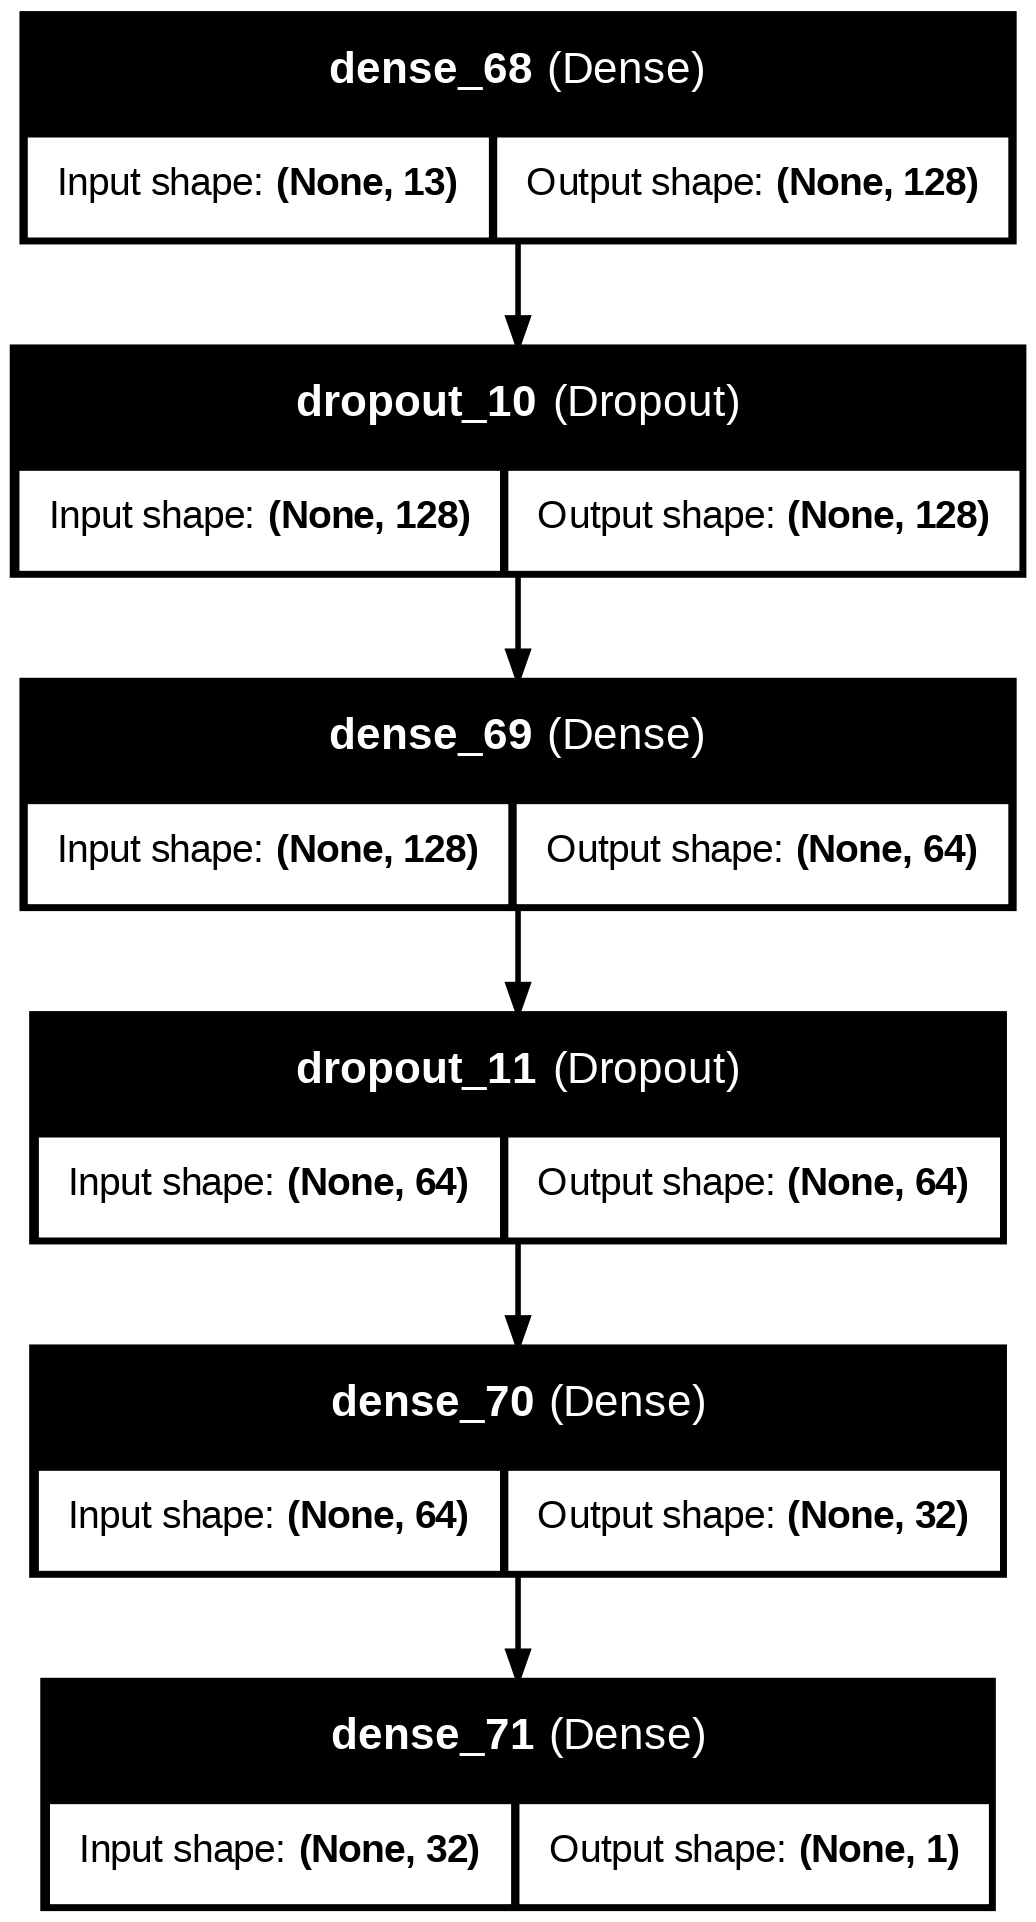

In [39]:
from keras.utils import plot_model
from IPython.display import Image
plot_model(
    best_shallow_model,
    show_shapes=True,
    show_layer_names=True,
    dpi=100
)
plot_model(
    best_shallow_model,
    to_file="shallow_nn.png",
    show_shapes=True,
    show_layer_names=True
)
Image("shallow_nn.png")
plot_model(
    best_deep_model,
    to_file="deep_nn.png",
    show_shapes=True,
    show_layer_names=True
)
Image("deep_nn.png")